# LIBRA and the Liquid Immersion Blanket
## 1L BABY
- Wall permeation
- FLiBe handing (ClLiF)
- Wall materials
- Tritium probe 

In [1]:
import math
import openmc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
import helpers
from openmc_model import baby_model

### Geometry

In [2]:
model = baby_model()
geometry = model.geometry

isotopes ['Al27', 'Ar36', 'Ar38', 'Ar40', 'B10', 'B11', 'C12', 'C13', 'Ca40', 'Ca42', 'Ca43', 'Ca44', 'Ca46', 'Ca48', 'Cl35', 'Cl37', 'Co59', 'Cr50', 'Cr52', 'Cr53', 'Cr54', 'Cu63', 'Cu65', 'F19', 'Fe54', 'Fe56', 'Fe57', 'Fe58', 'H1', 'H2', 'He3', 'He4', 'K39', 'K40', 'K41', 'Li6', 'Li7', 'Mg24', 'Mg25', 'Mg26', 'Mn55', 'Mo100', 'Mo92', 'Mo94', 'Mo95', 'Mo96', 'Mo97', 'Mo98', 'N14', 'N15', 'Na23', 'Nb93', 'Ni58', 'Ni60', 'Ni61', 'Ni62', 'Ni64', 'O16', 'O17', 'O18', 'P31', 'Pb204', 'Pb206', 'Pb207', 'Pb208', 'S32', 'S33', 'S34', 'S36', 'Si28', 'Si29', 'Si30', 'Ti46', 'Ti47', 'Ti48', 'Ti49', 'Ti50', 'Zr90', 'Zr91', 'Zr92', 'Zr94', 'Zr96']
Searching libraries with the following priority {'ENDFB-8.0-NNDC': 1}
Isotopes found matching library requirements 556
Isotopes found matching particle requirements 1789
Isotopes found matching isotope requirements 325
Isotopes found matching all requirements 82
             library remote_file  \
1233  ENDFB-8.0-NNDC       H1.h5   
1234  ENDFB-8.0-NNDC

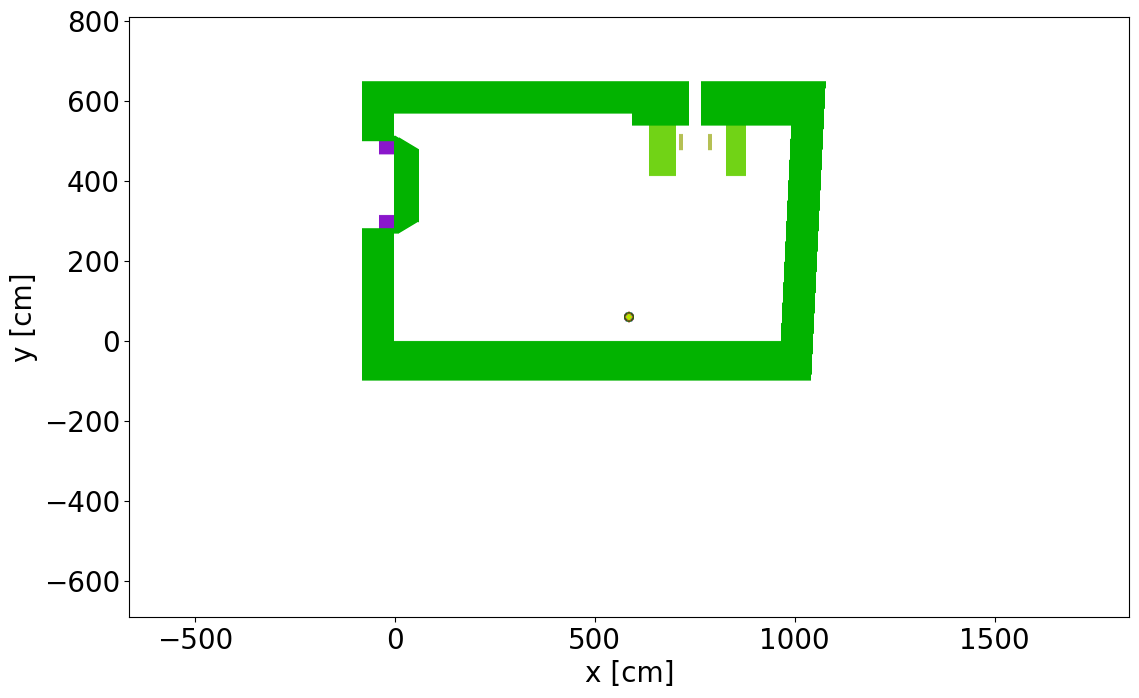

In [4]:
# Visualization

from libra_toolbox.neutronics.materials import Air
from openmc_model import air

x_c = 587
y_c = 60
z_c = 100
ax = geometry.plot(
    width=(2500, 1500),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.show()

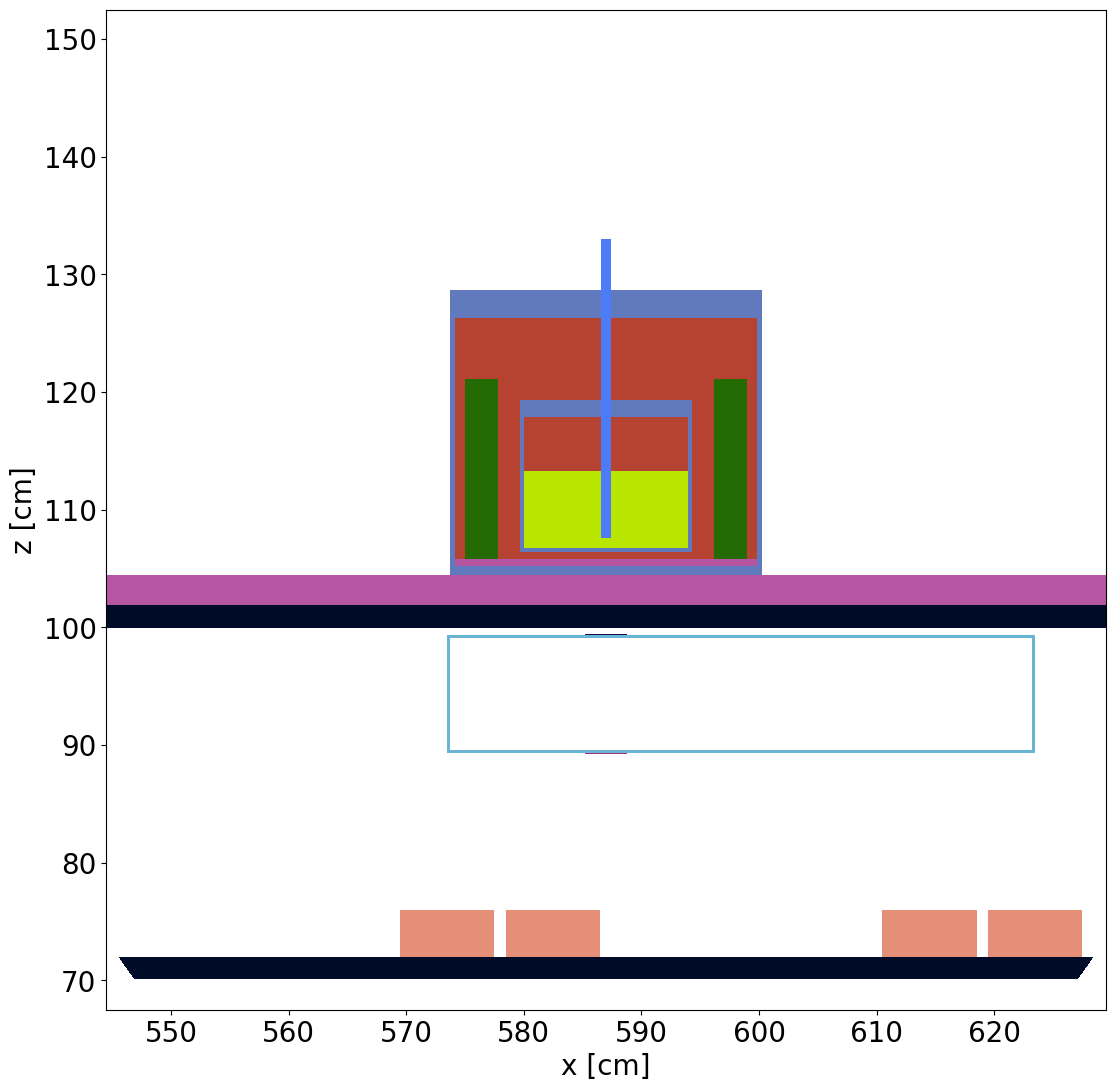

In [5]:
ax = geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xz",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.show()

### Result

In [6]:
sp = openmc.StatePoint("statepoint.100.h5") 
tbr_withvault = sp.get_tally(name="TBR")
tbr_mean = tbr_withvault.mean.sum()
tbr_std = tbr_withvault.std_dev.sum()
print(f"TBR: {tbr_mean:.6e}\n")
print(f"TBR std. dev.: {tbr_std:.6e}\n")
lithium_6_contribution = tbr_withvault.get_values(nuclides=['Li6'], value='mean').sum()
lithium_7_contribution = tbr_withvault.get_values(nuclides=['Li7'], value='mean').sum()
print(f"The tritium breeding by lithium 6 is: {lithium_6_contribution :.6e}")
print(f"The tritium breeding by lithium 7 is: {lithium_7_contribution :.6e}")

TBR: 1.992665e-03

TBR std. dev.: 9.708469e-06

The tritium breeding by lithium 6 is: 6.396543e-04
The tritium breeding by lithium 7 is: 1.353010e-03


In [7]:
tbr_mesh_result = sp.get_tally(name="UM_TBR")
unstructured_mesh = sp.meshes[1]
mean_data = np.squeeze(tbr_mesh_result.mean)  
std_dev_data = np.squeeze(tbr_mesh_result.std_dev)  

unstructured_mesh.write_data_to_vtk(
    filename="um_tbr.vtk",
    datasets={"mean": mean_data, 
              "std_dev": std_dev_data},
)